# Multiple Linear Regression:

- Multiple linear regression (MLR) is a statistical method that models the relationship between one dependent variable and two or more independent variables by fitting a straight-line equation to the data.
- The goal is to explain the outcome value as a weighted sum of the independent variables, allowing for the assessment of their individual and simultaneous influence on the outcome while controlling for potential confounders.
- The equation for MLR is:  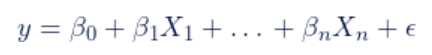
    - y = the predicted value of the dependent variable
    - B_0 = the y-intercept (value of y when all other parameters are set to 0)
    - B_1X_1 = the regression coefficient (B_1) of the first independent variable (X_1) (a.k.a. the effect that increasing the value of the independent variable has on the predicted y value)
    - … = do the same for however many independent variables you are testing
    - B_nX_n = the regression coefficient of the last independent variable
    - \epsilon = model error (a.k.a. how much variation there is in our estimate of y)

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

#### Example 1:

In [3]:
df = pd.read_csv('50_Startups.csv')

In [4]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


- We have 3 Continuous Variables and One Categorical Variable.
- Target (Profit) is Continuous Variable.

In [8]:
# Splitting Data into Independent and Dependent Variables:

X = df.drop('Profit', axis= 1)
y = df['Profit']

In [9]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [10]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 4)
(10, 4)
(40,)
(10,)


In [11]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [12]:
# List for Numerical and Categorical Column Names:
numerical_features = ['R&D Spend', 'Administration', 'Marketing Spend']
categorical_features = ['State']

In [13]:
# Defining Column Transaformations (Scaling For Numeric Features and Encoding For Categorical Features):

preprocessor = ColumnTransformer(transformers= [
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown= 'ignore'), categorical_features)]
)

In [14]:
# Transforming Training and testing Data:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [15]:
X_train

array([[ 0.34202149,  0.22787678,  0.12425038,  0.        ,  1.        ,
         0.        ],
       [ 1.36207849, -1.0974737 ,  1.14990688,  0.        ,  1.        ,
         0.        ],
       [-0.71081297, -2.5770186 , -0.34136825,  1.        ,  0.        ,
         0.        ],
       [ 0.90611438,  1.0172367 ,  0.66890185,  0.        ,  0.        ,
         1.        ],
       [ 1.40997088, -0.09115403,  1.30006861,  0.        ,  0.        ,
         1.        ],
       [ 1.20367103,  0.96116332, -0.95248784,  1.        ,  0.        ,
         0.        ],
       [-1.05285826, -1.34392538, -0.62843389,  0.        ,  1.        ,
         0.        ],
       [-1.61480906, -0.19649414,  0.54106768,  0.        ,  1.        ,
         0.        ],
       [-1.642623  ,  0.52691442, -2.07854935,  1.        ,  0.        ,
         0.        ],
       [ 0.77885123,  0.05437051,  0.2294954 ,  0.        ,  0.        ,
         1.        ],
       [ 0.96515572, -0.45976843,  0.61043134,  1.

In [16]:
X_test

array([[ 0.30245367,  0.52942836,  0.14916233,  1.        ,  0.        ,
         0.        ],
       [-0.82734624, -1.40769369, -0.53560477,  1.        ,  0.        ,
         0.        ],
       [-0.33181874, -0.20294703, -1.27505783,  0.        ,  1.        ,
         0.        ],
       [-1.62147425,  0.11103854, -2.06176266,  0.        ,  0.        ,
         1.        ],
       [ 0.35879726,  0.88291223,  0.41286919,  0.        ,  0.        ,
         1.        ],
       [-1.63116196, -2.56004955, -2.07854935,  0.        ,  0.        ,
         1.        ],
       [-0.04987791,  0.84817808, -0.89664846,  0.        ,  1.        ,
         0.        ],
       [-0.2753597 ,  0.67912498, -0.86215204,  1.        ,  0.        ,
         0.        ],
       [-0.30191325,  0.29793642, -1.67222209,  1.        ,  0.        ,
         0.        ],
       [ 0.18462534,  1.19412269, -2.07854935,  0.        ,  0.        ,
         1.        ]])

In [18]:
# Linear Regression Model:

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
# Predictions Using Model:
y_pred = lr.predict(X_test)

In [20]:
y_pred

array([126362.87908252,  84608.45383643,  99677.49425155,  46357.46068582,
       128750.48288497,  50912.41741905, 109741.350327  , 100643.24281644,
        97599.275746  , 113097.42524437])

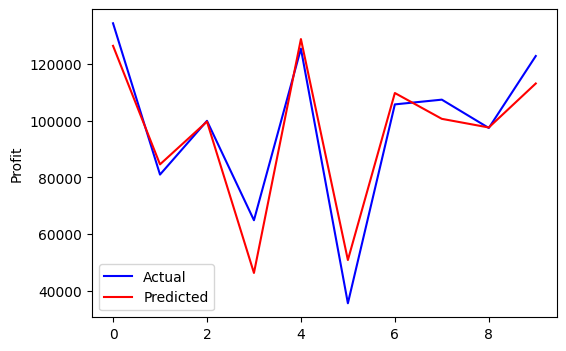

In [21]:
# Plotting Test Data vs Predictions:

x_range = range(len(y_test))

plt.figure(figsize= (6,4))
sns.lineplot(x= x_range, y= y_test, color= 'blue', label= 'Actual')
sns.lineplot(x= x_range, y= y_pred, color= 'red', label= 'Predicted')
plt.legend()
plt.show()

In [22]:
# Model Evaluation:

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

MAE: 6961.477813275558
MSE: 82010363.04501356
RMSE: 9055.957323497807
R2-Score: 0.8987266414319838


#### Example 2:

In [24]:
df = pd.read_csv('Advertising.csv')

In [25]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [26]:
df = df.drop('Unnamed: 0', axis= 1)

In [27]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [29]:
df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


- All Independent Variables are Numerical.
- Target (sales) is also a Continuous Variable.

In [30]:
# Separating Features and Target Variables:

X = df.drop('sales', axis= 1)
y = df['sales']

In [31]:
X.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [32]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [33]:
# Train Test Split:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 3)
(40, 3)
(160,)
(40,)


In [35]:
# Defining Column Transaformations (Scaling For Numeric Features):

preprocessor = ColumnTransformer(transformers= [('num', StandardScaler(), [0, 1, 2])]) # Using Column Indexes that we want to transform

In [36]:
# Transforming Training and Test Data:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [37]:
# Linear Regression Model:

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
# Predictions using Model:

y_pred = lr.predict(X_test)

In [40]:
y_pred

array([16.4080242 , 20.88988209, 21.55384318, 10.60850256, 22.11237326,
       13.10559172, 21.05719192,  7.46101034, 13.60634581, 15.15506967,
        9.04831992,  6.65328312, 14.34554487,  8.90349333,  9.68959028,
       12.16494386,  8.73628397, 16.26507258, 10.27759582, 18.83109103,
       19.56036653, 13.25103464, 12.33620695, 21.30695132,  7.82740305,
        5.80957448, 20.75753231, 11.98138077,  9.18349576,  8.5066991 ,
       12.46646769, 10.00337695, 21.3876709 , 12.24966368, 18.26661538,
       20.13766267, 14.05514005, 20.85411186, 11.0174441 ,  4.56899622])

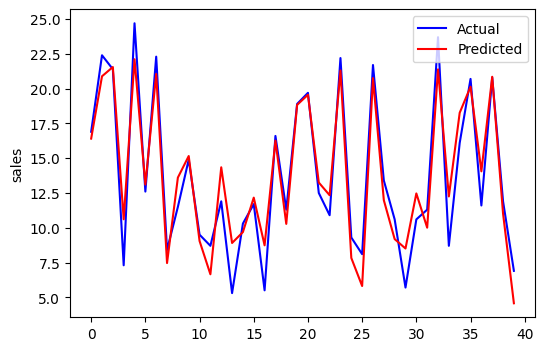

In [42]:
# Plotting Test Data vs Predictions:

x_range = range(len(y_test))

plt.figure(figsize= (6,4))
sns.lineplot(x= x_range, y= y_test, color= 'blue', label= 'Actual')
sns.lineplot(x= x_range, y= y_pred, color= 'red', label= 'Predicted')
plt.legend()
plt.show()

In [43]:
# Model Evaluation:

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}')
print(f'R2-Score: {r2_score(y_test, y_pred)}')

MAE: 1.46075671681176
MSE: 3.1740973539761037
RMSE: 1.78159966153345
R2-Score: 0.899438024100912
